In [1]:
import os
from matplotlib import axis
import pandas as pd
import numpy as np
from Bio import SeqIO
from Bio.Seq import Seq
# --------------------------------
from scipy.stats import mannwhitneyu, ttest_ind, pearsonr
from scipy.cluster.hierarchy import linkage, leaves_list
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from statsmodels.formula.api import ols
# --------------------------------
from tqdm.notebook import tqdm
# ----------------------------------------------------------------
from opts.plotting import plot_2dd_scatter
from lets_plot import *
LetsPlot.setup_html()
base_size = 14
tsne_plot_width = 650
theme_settings = theme(
    axis_text=element_text(size=base_size),
    axis_title=element_text(size=base_size * 1.2),
    legend_title=element_text(size=base_size * 1.2),
    legend_text=element_text(size=base_size * 0.9),
    plot_title=element_text(size=base_size * 1.4),
    axis_line_x=element_line(color='black', size=0.5),
    axis_ticks_x=element_line(color='black', size=0.5),
    axis_ticks_y=element_line(color='black', size=0.5),
    axis_line_y=element_line(color='black', size=0.5)
)

In [2]:
# manual interval overlap detection

import pyranges as pr

def find_overlaps(source_df, query_df):
    """
    Find overlapping intervals between source and query dataframes.
    Returns the source intervals that overlap with query intervals.
    
    Two intervals [a1, a2) and [b1, b2) overlap if: a1 < b2 AND b1 < a2
    """
    results = []
    for idx_q, row_q in query_df.iterrows():
        query_chr = row_q['chrom']
        query_start = row_q['start']
        query_end = row_q['end']
        query_strand = row_q['strand']
        
        source_filtered = source_df[
            (source_df['chrom'] == query_chr) & 
            (source_df['strand'] == query_strand)
        ]
        
        overlaps = source_filtered[
            (source_filtered['start'] < query_end) & 
            (query_start < source_filtered['end'])
        ].copy()
        
        if len(overlaps) > 0:
            overlaps['query_name'] = row_q['name']
            overlaps['query_start'] = query_start
            overlaps['query_end'] = query_end
            results.append(overlaps)
    if results:
        return pd.concat(results, ignore_index=True)
    else:
        return pd.DataFrame()

In [3]:
# chi-square wrapper

from scipy.stats import chi2_contingency
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests
from openpyxl.styles import Font, PatternFill
from openpyxl.utils import get_column_letter

def write_chi_square_report(tab_plotting_grpd_melted, out_xlsx):

    contingency = tab_plotting_grpd_melted.pivot_table(
        index="stability",
        columns="detained_introns",
        values="count",
        aggfunc="sum",
        fill_value=0,
        observed=False
    )

    # chi-square
    chi2, pval, dof, expected = chi2_contingency(contingency)
    expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)

    n = contingency.to_numpy().sum()
    r, k = contingency.shape
    cramers_v = np.sqrt(chi2 / (n * (min(r, k) - 1)))
    contingency_coeff = np.sqrt(chi2 / (chi2 + n))

    summary_df = pd.DataFrame({
        "Metric": ["Chi-square statistic", "Degrees of freedom", "P-value", "Cramér's V", "Contingency coefficient"],
        "Value": [chi2, dof, pval, cramers_v, contingency_coeff]
    })

    obs = contingency.copy()
    obs_values = obs.to_numpy()
    exp_values = expected

    pearson_res = (obs_values - exp_values) / np.sqrt(exp_values)
    pearson_res_df = pd.DataFrame(pearson_res, index=obs.index, columns=obs.columns)

    row_prop = obs_values.sum(axis=1, keepdims=True) / n
    col_prop = obs_values.sum(axis=0, keepdims=True) / n
    adj_res = (obs_values - exp_values) / np.sqrt(exp_values * (1 - row_prop) * (1 - col_prop))
    adj_res_df = pd.DataFrame(adj_res, index=obs.index, columns=obs.columns)

    p_cell = 2 * (1 - norm.cdf(np.abs(adj_res)))
    rej, qvals, _, _ = multipletests(p_cell.ravel(), method="fdr_bh")
    q_cell_df = pd.DataFrame(qvals.reshape(obs.shape), index=obs.index, columns=obs.columns)
    sig_cell_df = pd.DataFrame(rej.reshape(obs.shape), index=obs.index, columns=obs.columns)

    label_df = pd.DataFrame("ns", index=obs.index, columns=obs.columns)
    label_df[(adj_res_df > 0) & sig_cell_df] = "overrepresented"
    label_df[(adj_res_df < 0) & sig_cell_df] = "underrepresented"

    # Title style for worksheet section headers.
    title_font = Font(bold=True, color="FFFFFF")
    title_fill = PatternFill(fill_type="solid", fgColor="4F81BD")

    # export to excel and pray that it's pretty
    with pd.ExcelWriter(out_xlsx, engine="openpyxl") as writer:
        summary_df.to_excel(writer, sheet_name="chi_square_test", index=False, startrow=1)
        contingency.to_excel(writer, sheet_name="chi_square_test", startrow=8)
        expected_df.round(3).to_excel(writer, sheet_name="chi_square_test", startrow=15)

        obs.to_excel(writer, sheet_name="cellwise_results", startrow=1)
        expected_df.round(3).to_excel(writer, sheet_name="cellwise_results", startrow=8)
        pearson_res_df.round(3).to_excel(writer, sheet_name="cellwise_results", startrow=15)
        adj_res_df.round(3).to_excel(writer, sheet_name="cellwise_results", startrow=22)
        q_cell_df.round(6).to_excel(writer, sheet_name="cellwise_results", startrow=29)
        label_df.to_excel(writer, sheet_name="cellwise_results", startrow=36)

        wb = writer.book
        ws1 = wb["chi_square_test"]
        ws2 = wb["cellwise_results"]

        ws1["A1"] = "Global chi-square test summary"
        ws1["A8"] = "Observed contingency table"
        ws1["A15"] = "Expected counts under independence"

        ws2["A1"] = "Observed counts"
        ws2["A8"] = "Expected counts"
        ws2["A15"] = "Pearson residuals"
        ws2["A22"] = "Adjusted residuals"
        ws2["A29"] = "FDR q-values"
        ws2["A36"] = "Cell interpretation"

        for ws in [ws1, ws2]:
            ws["A1"].font = title_font
            ws["A1"].fill = title_fill
            for col_cells in ws.columns:
                max_len = max(len(str(c.value)) if c.value is not None else 0 for c in col_cells)
                ws.column_dimensions[get_column_letter(col_cells[0].column)].width = min(max_len + 2, 40)
            ws.freeze_panes = "A2"
    return {
        "chi2": chi2,
        "pval": pval,
        "dof": dof,
        "cramers_v": cramers_v,
        "contingency_coeff": contingency_coeff,
        "contingency": contingency,
        "expected_df": expected_df,
        "adj_res_df": adj_res_df,
        "q_cell_df": q_cell_df,
        "label_df": label_df
    }

In [4]:
## paths

dir_data = os.path.join('resubmission', 'data')
dir_rev = os.path.join(dir_data, 'revision')
dir_results = os.path.join('resubmission', 'results')
dir_plotting = os.path.join(dir_results, 'plots')

In [5]:
## load necessary tables

introns_source = pd.read_csv(os.path.join(dir_data, 'all_vastdb_introns_source.csv'))
tab_meta = pd.read_csv(os.path.join(dir_data, 'metadata_selected.csv'), index_col=0)
tab_meta['Relative_Intron_Position'] = tab_meta['Intron_Position'] / tab_meta['Total_Introns']
tab_meta['loglength'] = np.log10(tab_meta['LENGTH'])

In [ ]:
## match detained introns with vastDB introns

for bed_name in ['cbraun_dintrons_hg38', 'psharp_dintrons_hg38']:
    bed_ints = pd.read_csv(
        os.path.join(dir_rev, f'{bed_name}.bed'),
        sep='\t', header=None
    )
    bed_ints.columns = ['chrom', 'start', 'end', 'name', 'score', 'strand']
    ##
    mapped_events = find_overlaps(introns_source, bed_ints)
    mapped_events.to_csv(os.path.join(dir_rev, f'{bed_name}_vastDBmapped.tsv'), sep='\t', index=False)
    ##
    print(f"Found {len(mapped_events)} overlapping interval pairs")
    print(f"\nExample matches:")
    print(mapped_events[['GENE', 'EVENT', 'chrom', 'start', 'end', 'query_name', 'query_start', 'query_end']].head(15))


    if not 'mapped_events' in locals():
        mapped_events = pd.read_csv(os.path.join(dir_rev, f'{bed_name}_vastDBmapped.tsv'), sep='\t')

    def get_best_overlap(group):
        """Get the EVENT with the largest overlap"""
        group['overlap_size'] = np.minimum(group['query_end'], group['end']) - np.maximum(group['query_start'], group['start'])
        best_idx = group['overlap_size'].idxmax()
        return group.loc[best_idx, 'EVENT']

    mapped_events_best = mapped_events.groupby('query_name').apply(get_best_overlap, include_groups=False).reset_index()
    mapped_events_best.columns = ['name', 'EVENT']
    print(f"Filtered {len(mapped_events)} ---> {len(mapped_events_best)}")
    mapped_events_best.to_csv(os.path.join(dir_rev, f'{bed_name}_vastDBmappedBestOverlap.tsv'), sep='\t', index=False)

In [30]:
## compare detained intron sets with our stability groups and the half-life data
for dint_bed in ['cbraun_dintrons_hg38', 'psharp_dintrons_hg38']:
    dint_name = dint_bed.replace('_hg38', '')
    dint_overlap = pd.read_csv(os.path.join(dir_rev, f'{dint_bed}_vastDBmappedBestOverlap.tsv'), sep='\t')
    tab_plotting = tab_meta.merge(
        dint_overlap[['EVENT']],
        how='inner',
        on='EVENT'
    ).query('stability != "IR_unclassified"')
    ## ---
    tmp = pd.DataFrame(tab_plotting.groupby('stability').size())
    tmp.columns = ['count']
    tmp['stability'] = tmp.index
    ## ---
    tab_plotting['stability'] = 'Detained'
    tab_plotting = pd.concat([tab_meta, tab_plotting])
    tab_plotting['stability'] = pd.Categorical(
        tab_plotting['stability'],
        categories=['Stable_4h', 'Unstable_4h', 'Unstable_2h', 'Unstable_30min', 'Detained', 'noIR'],
        ordered=True
    )
    pdict = {}
    pdict['hl_scaled'] = ggplot(data=tab_plotting) +\
        geom_boxplot(aes(y='hl_gated_intwise_scaled_logged', x='stability'),
                     width=.85, outlier_size=0.7, outlier_alpha=0.35) +\
        geom_hline(yintercept=-.7, linetype='solid', color='#2a1f3f', size=1.25) +\
        geom_hline(yintercept=-1.5, linetype='solid', color='#a76794', size=1.25) +\
        theme_settings +\
        theme(axis_text_x=element_text(angle=45, hjust=1)) +\
        labs(y='log(Intron HL / Gene HL)', x='Category') +\
        ggsize(280, 500)
    pdict['hl_raw'] = ggplot(data=tab_plotting) +\
        geom_boxplot(aes(y='hl_gated_intwise', x='stability'),
                     width=.85, outlier_size=0.7, outlier_alpha=0.35) +\
        theme_settings +\
        theme(axis_text_x=element_text(angle=45, hjust=1)) +\
        labs(y='Intron Half-life [hours]', x='Category') +\
        ggsize(280, 500)
    pdict['pir'] = ggplot(data=tab_plotting) +\
        geom_boxplot(aes(y='PIR_Nuc_baseline', x='stability'),
                     width=.85, outlier_size=0.7, outlier_alpha=0.35) +\
        geom_hline(yintercept=30, linetype='solid', color='#2a1f3f', size=1.25) +\
        theme_settings +\
        theme(axis_text_x=element_text(angle=45, hjust=1)) +\
        labs(y='Basal intron retentnio [PIR]', x='Category') +\
        ggsize(280, 500)
    pdict['speck'] = ggplot(data=tab_plotting) +\
        geom_boxplot(aes(y='Speckle_Enrichment', x='stability'),
                     width=.85, outlier_size=0.7, outlier_alpha=0.35) +\
        geom_hline(yintercept=0, linetype='solid', color='#2a1f3f', size=1.25) +\
        theme_settings +\
        theme(axis_text_x=element_text(angle=45, hjust=1)) +\
        labs(y='Speckle Enrichment [lg2FC]', x='Category') +\
        ggsize(280, 500)
    pdict['gc'] = ggplot(data=tab_plotting) +\
        geom_boxplot(aes(y='GC_Content', x='stability'),
                     width=.85, outlier_size=0.7, outlier_alpha=0.35) +\
        geom_hline(yintercept=50, linetype='solid', color='#2a1f3f', size=1.25) +\
        theme_settings +\
        theme(axis_text_x=element_text(angle=45, hjust=1)) +\
        labs(y='GC Content [%]', x='Category') +\
        ggsize(280, 500)
    pdict['rip'] = ggplot(data=tab_plotting) +\
        geom_boxplot(aes(y='Relative_Intron_Position', x='stability'),
                     width=.85, outlier_size=0.7, outlier_alpha=0.35) +\
        geom_hline(yintercept=0.5, linetype='solid', color='#2a1f3f', size=1.25) +\
        theme_settings +\
        theme(axis_text_x=element_text(angle=45, hjust=1)) +\
        labs(y='Relative Intron Position\n[n intron / total introns]', x='Category') +\
        ggsize(280, 500)
    pdict['llength'] = ggplot(data=tab_plotting) +\
        geom_boxplot(aes(y='loglength', x='stability'),
                     width=.85, outlier_size=0.7, outlier_alpha=0.35) +\
        theme_settings +\
        theme(axis_text_x=element_text(angle=45, hjust=1)) +\
        labs(y='Log10 Intron Length', x='Category') +\
        ggsize(280, 500)
    for pname, p in pdict.items():
        ggsave(p, path=dir_plotting, filename=f'SFN_{dint_name}_{pname}.svg')

In [31]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import itertools

anova_results = {}
tukey_results = {}

plot_vars = {
    'hl_scaled': 'hl_gated_intwise_scaled_logged',
    'hl_raw': 'hl_gated_intwise',
    'pir': 'PIR_Nuc_baseline',
    'speck': 'Speckle_Enrichment',
    'gc': 'GC_Content',
    'rip': 'Relative_Intron_Position',
    'llength': 'loglength'
}

for dint_bed in ['cbraun_dintrons_hg38', 'psharp_dintrons_hg38']:
    dint_name = dint_bed.replace('_hg38', '')
    dint_overlap = pd.read_csv(os.path.join(dir_rev, f'{dint_bed}_vastDBmappedBestOverlap.tsv'), sep='\t')

    tab_plotting = tab_meta.merge(
        dint_overlap[['EVENT']],
        how='inner',
        on='EVENT'
    ).query('stability != "IR_unclassified"')

    tab_plotting['stability'] = 'Detained'
    tab_plotting = pd.concat([tab_meta, tab_plotting])
    tab_plotting['stability'] = pd.Categorical(
        tab_plotting['stability'],
        categories=['Stable_4h', 'Unstable_4h', 'Unstable_2h', 'Unstable_30min', 'Detained', 'noIR'],
        ordered=True
    )
    tab_plotting = tab_plotting.query('stability != "IR_unclassified"').dropna(subset=['stability'])

    print(f"\n{'='*80}")
    print(f"Dataset: {dint_name}")
    print(f"{'='*80}")

    for pname, col in plot_vars.items():
        df_sub = tab_plotting[['stability', col]].dropna()
        if df_sub.empty or df_sub['stability'].nunique() < 2:
            print(f"\n[{pname}] Skipping — insufficient data")
            continue

        # Two-way ANOVA (one factor here: stability; using OLS formula)
        formula = f'Q("{col}") ~ C(stability)'
        try:
            model = ols(formula, data=df_sub).fit()
            anova_table = sm.stats.anova_lm(model, typ=2)

            print(f"\n--- {pname} ({col}) ---")
            print("Two-way ANOVA:")
            print(anova_table.to_string())

            anova_results[(dint_name, pname)] = anova_table

            # Tukey HSD post hoc
            tukey = pairwise_tukeyhsd(
                endog=df_sub[col],
                groups=df_sub['stability'],
                alpha=0.05
            )
            tukey_df = pd.DataFrame(
                data=tukey._results_table.data[1:],
                columns=tukey._results_table.data[0]
            )
            print("\nTukey HSD post hoc (significant pairs only):")
            sig_tukey = tukey_df[tukey_df['reject'] == True]
            if sig_tukey.empty:
                print("  No significant pairwise differences found.")
            else:
                print(sig_tukey.to_string(index=False))

            group_means = df_sub.groupby('stability', observed=True)[col].mean()
            tukey_df['mean_group_A'] = tukey_df['group1'].map(group_means)
            tukey_df['mean_group_B'] = tukey_df['group2'].map(group_means)
            ordered_cols = ['group1', 'group2', 'mean_group_A', 'mean_group_B'] + [
                c for c in tukey_df.columns if c not in ['group1', 'group2', 'mean_group_A', 'mean_group_B']
            ]
            tukey_df = tukey_df[ordered_cols]

            tukey_results[(dint_name, pname)] = tukey_df

            # Export to csv
            out_path = os.path.join(dir_plotting, f'SFN_{dint_name}_{pname}_anova_tukey.csv')
            combined = tukey_df.copy()
            combined.insert(0, 'variable', col)
            combined.insert(0, 'dataset', dint_name)
            combined.to_csv(out_path, index=False)

        except Exception as e:
            print(f"\n[{pname}] Error during ANOVA/Tukey: {e}")


Dataset: cbraun_dintrons

--- hl_scaled (hl_gated_intwise_scaled_logged) ---
Two-way ANOVA:
                   sum_sq       df           F  PR(>F)
C(stability)  3004.019169      5.0  1924.87107     0.0
Residual      8265.741730  26482.0         NaN     NaN

Tukey HSD post hoc (significant pairs only):
        group1         group2  meandiff  p-adj   lower   upper  reject
      Detained      Stable_4h    0.7203 0.0000  0.6577  0.7829    True
      Detained    Unstable_2h   -0.1545 0.0000 -0.2135 -0.0956    True
      Detained Unstable_30min   -0.4618 0.0000 -0.5432 -0.3804    True
      Detained    Unstable_4h    0.2571 0.0000  0.1727  0.3415    True
      Detained           noIR   -0.5702 0.0000 -0.6188 -0.5217    True
     Stable_4h    Unstable_2h   -0.8748 0.0000 -0.9290 -0.8207    True
     Stable_4h Unstable_30min   -1.1821 0.0000 -1.2601 -1.1042    True
     Stable_4h    Unstable_4h   -0.4632 0.0000 -0.5443 -0.3821    True
     Stable_4h           noIR   -1.2905 0.0000 -1.3331 -1

In [15]:
## plot count overlap of detained introns with our stability groups

for dint_bed in ['cbraun_dintrons_hg38', 'psharp_dintrons_hg38']:
    dint_name = dint_bed.replace('_hg38', '')
    dint_overlap = pd.read_csv(os.path.join(dir_rev, f'{dint_bed}_vastDBmappedBestOverlap.tsv'), sep='\t')
    dint_overlap['Detained\nIntrons'] = dint_name
    tab_plotting = tab_meta.merge(
        dint_overlap[['EVENT', 'Detained\nIntrons']],
        how='left',
        on='EVENT'
    ).drop_duplicates(subset=['EVENT'])
    tab_plotting['Detained\nIntrons'] = tab_plotting['Detained\nIntrons'].fillna('not_detained')
    tab_plotting_grpd = tab_plotting.groupby(['stability', 'Detained\nIntrons']).size().unstack(fill_value=0)
    tab_plotting_grpd['total'] = tab_plotting_grpd.sum(axis=1)
    tab_plotting_grpd['dummy_text'] = tab_plotting_grpd[dint_name].astype(str) + ' /\n' + tab_plotting_grpd['total'].astype(str)
    tab_plotting_grpd['rel_size'] = tab_plotting_grpd[dint_name] / tab_plotting_grpd['total']
    tab_plotting_grpd['dummy'] = ''
    tab_plotting_grpd = tab_plotting_grpd.query('stability != "IR_unclassified"')
    tab_plotting_grpd.reset_index(inplace=True)
    tab_plotting_grpd['stability'] = pd.Categorical(
        tab_plotting_grpd['stability'],
        categories=['Stable_4h', 'Unstable_4h', 'Unstable_2h', 'Unstable_30min', 'noIR'],
        ordered=True
    )
    ## tiles
    detained_frac_tiles = ggplot(
        data=tab_plotting_grpd
    ) +\
    geom_tile(aes(y='dummy', x='stability', fill='rel_size'), size=.25, color='black', width=0.9, height=0.25) +\
    geom_text(aes(y='dummy', x='stability', label='dummy_text'), color='white', size=8) +\
    scale_fill_gradient(low='#a76794', high='#2a1f3f') +\
    labs(x='Stability category', y='', fill=f'Fraction of\ndetained\nintrons') +\
    theme_settings +\
    ggsize(450, 280)
    ##
    ggsave(
        detained_frac_tiles, path=dir_plotting,
        filename=f'SFN_{dint_name}_detained_fraction_tiles.svg'
    )

    ## bars
    tab_plotting_grpd_melted = tab_plotting_grpd.melt(
        id_vars=['stability'], value_vars=[dint_name, 'not_detained'],
        var_name='detained_introns', value_name='count'
    )
    ##
    detained_frac_bars = ggplot(
        data=tab_plotting_grpd_melted
    ) +\
        geom_bar(
            aes(x='stability', y='count', fill='detained_introns'),
            stat='identity', position_dodge=.8, size=.25, color='black', width=.8
        ) +\
        scale_fill_manual(values={'No overlap': '#a76794', dint_name: '#2a1f3f'}) +\
        theme_settings +\
        labs(x='Stability category', y='Count', fill='Detained introns') +\
            coord_cartesian(ylim=(0, 5000)) +\
        ggsize(400, 400)
    ##
    ggsave(
        detained_frac_bars, path=dir_plotting,
        filename=f'SFN_{dint_name}_detained_fraction_bars.svg'
    )
    write_chi_square_report(
        tab_plotting_grpd_melted,
        out_xlsx=os.path.join(dir_plotting, f'SFN_{dint_name}_detained_fraction_chisqrd.xlsx')
    )



----
plot contour of P.Sharp's detained introns in our embeddings 

In [7]:
import torch
import ir_toolkit.ir_toolkit as irt

In [18]:
@torch.no_grad()
def extract_side_means(loader, model_backbone, device='cuda', concat_both=True):
    ids_all, chunks = [], []

    for batch in loader:
        ids, left, left_mask, right, right_mask, middle, labels = batch
        B = left.shape[0]

        left  = left.to(device)         # [B, 4, L]
        right = right.to(device)        # [B, 4, L]
        lmsk  = left_mask.to(device)    # [B, L]
        rmsk  = right_mask.to(device)   # [B, L]

        fL = model_backbone(left)
        fR = model_backbone(right)

        lden = lmsk.sum(dim=1, keepdim=True).clamp_min(1e-8)  # [B,1]
        rden = rmsk.sum(dim=1, keepdim=True).clamp_min(1e-8)
        lvec = (fL * lmsk.unsqueeze(1).to(fL.dtype)).sum(dim=2) / lden
        rvec = (fR * rmsk.unsqueeze(1).to(fR.dtype)).sum(dim=2) / rden

        emb = torch.cat([lvec, rvec], dim=1) if concat_both else lvec
        chunks.append(emb.cpu())
        ids_all.extend(ids)

        embeds = torch.cat(chunks, dim=0)
        out = embeds.detach().cpu().numpy()

    return pd.DataFrame(out, index=ids_all)

In [19]:
from torch.utils.data import DataLoader

def build_loader(event_ids):
    # ir_toolkit.IntronsEndsDataset expects a 'class' column in the metadata frame
    source_data = pd.DataFrame({"class": 0.0}, index=event_ids)
    source_seqs = irt.load_fasta_to_dict(
        os.path.join(dir_data, "all_vastdb_introns_50fks.fasta"),
        ids_keep=set(event_ids),
        id_func=lambda x: x.split("_")[0]
    )
    ds = irt.IntronsEndsDataset(
        event_ids, source_seqs, source_data,
        L_left=256, L_right=256, use_middle=False
    )
    return DataLoader(
        ds,
        batch_size=64,
        shuffle=False,
        num_workers=4,
        collate_fn=irt.introns_collate_fn,
        drop_last=False
    )

---

In [7]:
## prepare embeds for t-SNEs
## ----
dir_models = '/lustre/groups/crna01/projects/collabs/shared/models/parnet'
rbp_order = pd.read_csv(os.path.join(dir_models, 'rbp_ord.txt'), header=None, names=['rbp'])
weights_path = os.path.join(dir_models, '0.5.0_RBPNet-11M.pt') #('../shared/models/parnet/RBPnet_21M_penalized.pt')
parnet_21 = torch.load(weights_path, map_location='cuda', weights_only=False)
# parnet_21.projection = lambda x: x
# parnet_21.head.use_maximum_target_control_logprob = False
# parnet_21.head.control_nograd = False
base_bb = irt.ParnetBackbone(parnet_21)
ckpt_path = "resubmission/results/models/HL_revised/parnet_512_jc_50percgap_256bp_PIR10/beststate_fold1/best_model_epoch=18_val_auroc=0.710.ckpt"
ckpt = torch.load(ckpt_path, map_location="cuda")
sd = ckpt["state_dict"] 
best_model = irt.IntronEndLightning(model=irt.IntronEndCAMModel(backbone=base_bb,
                                                         feat_dim=512, attn_hidden=256,
                                                         use_attention_pooling=True,
                                                         use_simple_fusion=False,
                                                         use_joint_classifier=True,
                                                         use_middle=False),
                            pos_weight=1)
best_model.load_state_dict(sd, strict=True)
best_model.to('cuda')
best_model.eval()

/ictstr01/groups/crna01/projects/collabs/shared/cenvs/parnet_clean/lib/python3.10/site-packages/gin/config.py:615: FutureWarning: `NLLLoss2d` has been deprecated. Please use `NLLLoss` instead as a drop-in replacement and see https://pytorch.org/docs/main/nn.html#torch.nn.NLLLoss for more details.
  decorated_class = decorating_meta(cls.__name__, (cls,), overrides)
[rank: 0] Seed set to 42
/ictstr01/groups/crna01/projects/collabs/shared/cenvs/parnet_clean/lib/python3.10/site-packages/parnet/constants.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during un

IntronEndLightning(
  (model): IntronEndCAMModel(
    (backbone): ParnetBackbone(
      (stem): StemConv1D(
        (conv1d): Conv1d(4, 512, kernel_size=(12,), stride=(1,), padding=same)
        (batch_norm): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): ReLU()
      )
      (body): Sequential(
        (0): ResConvBlock1D(
          (conv1d): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=same)
          (batch_norm): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): ReLU()
          (dropout): Dropout1d(p=0.25, inplace=False)
        )
        (1): ResConvBlock1D(
          (conv1d): Conv1d(512, 512, kernel_size=(3,), stride=(1,), padding=same)
          (batch_norm): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (act): ReLU()
          (dropout): Dropout1d(p=0.25, inplace=False)
        )
        (2): ResConvBlock1D(
          (conv1d

In [ ]:
# build reference (class_hls) and detained ID sets
high_cut, low_cut = -0.364742, -1.342584
pir_cut = 10

tmp_hls = tab_meta.query(
    'PIR_Nuc_baseline > @pir_cut'
).dropna(
    subset=['hl_gated_intwise_scaled_logged']
).copy()

class_conds = [
    tmp_hls['hl_gated_intwise_scaled_logged'] > high_cut,
    tmp_hls['hl_gated_intwise_scaled_logged'] < low_cut
]
class_names = ['LL-RIs', 'SL-RIs']
tmp_hls['class_hls'] = np.select(class_conds, class_names, default='else')

ref_df = tmp_hls.query("class_hls in ['LL-RIs', 'SL-RIs']").copy()
ref_ids = ref_df.index.astype(str).unique().tolist()

detained_ids = []
for dint_bed in ["cbraun_dintrons_hg38", "psharp_dintrons_hg38"]:
    p = os.path.join(dir_rev, f"{dint_bed}_vastDBmappedBestOverlap.tsv")
    d = pd.read_csv(p, sep="\t")
    detained_ids.extend(d["EVENT"].astype(str).unique().tolist())
detained_ids = sorted(set(detained_ids) - (set(ref_ids) & set(detained_ids)))

# 2) Build loaders with dataset-compatible label column
ref_loader = build_loader(ref_ids)
dint_loader = build_loader(detained_ids)

# 3) Extract embeddings
emb_ref = extract_side_means(
    ref_loader,
    model_backbone=best_model.model.backbone.eval(),
    device="cuda",
    concat_both=True
)
emb_dint = extract_side_means(
    dint_loader,
    model_backbone=best_model.model.backbone.eval(),
    device="cuda",
    concat_both=True
)

print(f"ref embeddings: {emb_ref.shape}")
print(f"detained embeddings: {emb_dint.shape}")

/ictstr01/groups/crna01/projects/collabs/shared/cenvs/parnet_clean/lib/python3.10/site-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at ../aten/src/ATen/native/Convolution.cpp:1036.)
  return F.conv1d(


ref embeddings: (6342, 1024)
detained embeddings: (11711, 1024)


In [ ]:
# fit UMAP on reference, transform detained
import umap
reducer = umap.UMAP(
    n_neighbors=50, min_dist=0.2, n_components=2, metric="cosine", random_state=42
)
xy_ref = reducer.fit_transform(emb_ref.values)
xy_dint = reducer.transform(emb_dint.values)

umap_ref = pd.DataFrame(xy_ref, index=emb_ref.index, columns=["UMAP1", "UMAP2"])
umap_dint = pd.DataFrame(xy_dint, index=emb_dint.index, columns=["UMAP1", "UMAP2"])
umap_all = pd.concat([umap_ref, umap_dint]).reset_index(names="EVENT")

In [47]:
detained_dict = {}
for dint_bed in ["cbraun_dintrons_hg38", "psharp_dintrons_hg38"]:
    p = os.path.join(dir_rev, f"{dint_bed}_vastDBmappedBestOverlap.tsv")
    d = pd.read_csv(p, sep="\t")
    detained_dict[dint_bed] = d["EVENT"].astype(str).unique().tolist()

for dint_bed, event_ids in detained_dict.items():
    dint_name = dint_bed.replace('_hg38', '')
    umap_all[dint_name] = umap_all['EVENT'].isin(event_ids).astype(str)
    umap_all.loc[~umap_all['EVENT'].isin(event_ids), dint_name] = np.nan

umap_all = umap_all.merge(
    tmp_hls.query("class_hls in ['LL-RIs', 'SL-RIs']")[['class_hls']],
    left_on='EVENT', right_index=True, how='left'
)

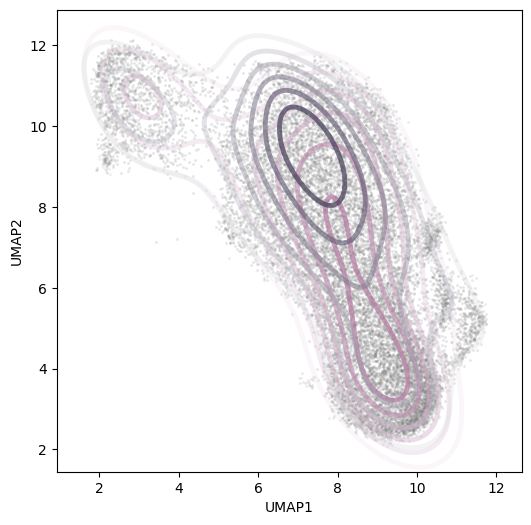

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

In [ ]:
plot_2dd_scatter(
    tab_data=umap_all,
    contour_col="class_hls",
    x_name="UMAP1",
    y_name="UMAP2",
    scat_alpha=0.2,
    contour_col_classes={'SL-RIs': '#a76794', 'LL-RIs': '#2a1f3f', 'else': 'grey'},
    dlevels=8,
    linewidth=3.5,
    kde_smooth=1.5,
    base_alpha=0.8,
    min_alpha=0.3,
    alpha_decay="linear",
    decay_rate=2.0,
    fig_size=(6, 6),
    show_plot=True,
    return_fig=False,
    file_name=os.path.join(dir_plotting, 'SFN_umap_refdetained.svg')
)

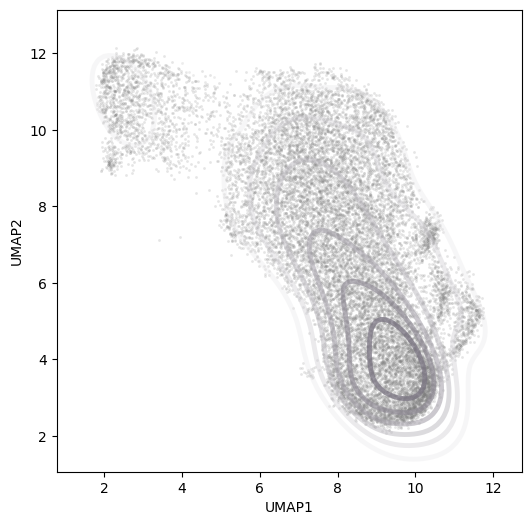

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

In [58]:
plot_2dd_scatter(
    tab_data=umap_all,
    contour_col="psharp_dintrons",
    x_name="UMAP1",
    y_name="UMAP2",
    scat_alpha=0.2,
    contour_col_classes={'True': '#635c6c'},
    dlevels=8,
    linewidth=3.5,
    kde_smooth=1.5,
    base_alpha=0.8,
    min_alpha=0.3,
    alpha_decay="linear",
    decay_rate=2.0,
    fig_size=(6, 6),
    show_plot=True,
    return_fig=False,
    file_name=os.path.join(dir_plotting, 'SFN_umap_mappedpsharp.svg')
)

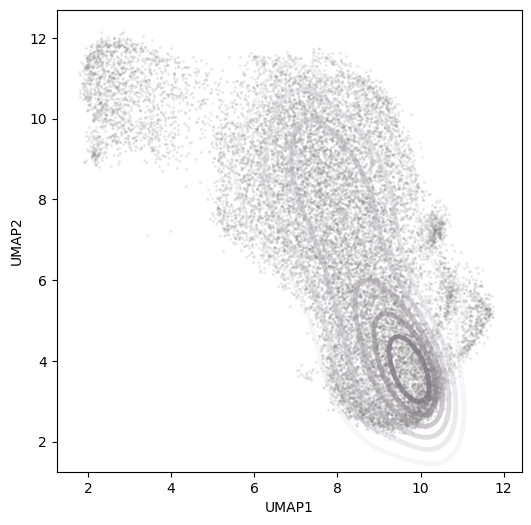

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

In [59]:
plot_2dd_scatter(
    tab_data=umap_all,
    contour_col="cbraun_dintrons",
    x_name="UMAP1",
    y_name="UMAP2",
    scat_alpha=0.2,
    contour_col_classes={'True': '#635c6c'},
    dlevels=8,
    linewidth=3.5,
    kde_smooth=1.5,
    base_alpha=0.8,
    min_alpha=0.3,
    alpha_decay="linear",
    decay_rate=2.0,
    fig_size=(6, 6),
    show_plot=True,
    return_fig=False,
    file_name=os.path.join(dir_plotting, 'SFN_umap_mappedcbraun.svg')
)

-----
visualize introns with probes

In [47]:
# TERT I11  HsaINT1044026
# FANCA I5 HsaINT1013334
# CENPT I11 HsaINT0033466
# BRD8 I9 HsaINT0018536
# METTL3 I8 (HsaINT0102211) & I9 (HsaINT1022852)
# RAD52 I10 HsaINT0136677
fishis = ['HsaINT1044026', 'HsaINT1013334', 'HsaINT0033466', 'HsaINT0018536', 'HsaINT0102211', 'HsaINT1022852', 'HsaINT0136677']
fishis_labels = {
    'HsaINT1044026': 'TERT I11',
    'HsaINT1013334': 'FANCA I5',
    'HsaINT0033466': 'CENPT I11',
    'HsaINT0018536': 'BRD8 I9',
    'HsaINT0102211': 'METTL3 I8',
    'HsaINT1022852': 'METTL3 I9',
    'HsaINT0136677': 'RAD52 I10'
}
# check if we have those in current umap reduction
tab_umap = pd.read_csv(
    os.path.join(dir_results, 'models', 'HL_revised', 'parnet_512_jc_50percgap_256bp_PIR10', 'umap_embeddings.csv'),
    index_col=0
)

In [20]:
# build reference (class_hls) and detained ID sets
high_cut, low_cut = -0.364742, -1.342584
pir_cut = 10

tmp_hls = tab_meta.query(
    'PIR_Nuc_baseline > @pir_cut'
).dropna(
    subset=['hl_gated_intwise_scaled_logged']
).copy()

class_conds = [
    tmp_hls['hl_gated_intwise_scaled_logged'] > high_cut,
    tmp_hls['hl_gated_intwise_scaled_logged'] < low_cut
]
class_names = ['LL-RIs', 'SL-RIs']
tmp_hls['class_hls'] = np.select(class_conds, class_names, default='else')

ref_df = tmp_hls.query("class_hls in ['LL-RIs', 'SL-RIs']").copy()
ref_ids = ref_df.index.astype(str).unique().tolist()

proj_ids = list(set(fishis) - set(tab_umap.index.astype(str)))

# 2) Build loaders with dataset-compatible label column
ref_loader = build_loader(ref_ids)
proj_loader = build_loader(proj_ids)

# 3) Extract embeddings
emb_ref = extract_side_means(
    ref_loader,
    model_backbone=best_model.model.backbone.eval(),
    device="cuda",
    concat_both=True
)
emb_proj = extract_side_means(
    proj_loader,
    model_backbone=best_model.model.backbone.eval(),
    device="cuda",
    concat_both=True
)

print(f"ref embeddings: {emb_ref.shape}")
print(f"proj embeddings: {emb_proj.shape}")

/ictstr01/groups/crna01/projects/collabs/shared/cenvs/parnet_clean/lib/python3.10/site-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at ../aten/src/ATen/native/Convolution.cpp:1036.)
  return F.conv1d(


ref embeddings: (6342, 1024)
proj embeddings: (3, 1024)


In [22]:
# fit UMAP on reference, transform detained
import umap
reducer = umap.UMAP(
    n_neighbors=50, min_dist=0.2, n_components=2, metric="cosine", random_state=42
)
xy_ref = reducer.fit_transform(emb_ref.values)
xy_proj = reducer.transform(emb_proj.values)

umap_ref = pd.DataFrame(xy_ref, index=emb_ref.index, columns=["UMAP1", "UMAP2"])
umap_proj = pd.DataFrame(xy_proj, index=emb_proj.index, columns=["UMAP1", "UMAP2"])
umap_all = pd.concat([umap_ref, umap_proj]).reset_index(names="EVENT")
umap_all.index = umap_all['EVENT']
umap_all = umap_all.drop(columns=['EVENT'])

2026-03-27 08:55:41.595246: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-27 08:55:51.297378: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-27 08:55:52.199772: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-27 08:55:52.200558: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-27 08:55:53.525863: I tensorflow/core/platform/cpu_feature_gua

In [35]:
tab_umap_fishis = umap_all.merge(
    tmp_hls,
    left_index=True, right_index=True, how='left'
)

In [49]:
import importlib
import opts.plotting as plotting

importlib.reload(plotting)
plot_2dd_scatter = plotting.plot_2dd_scatter

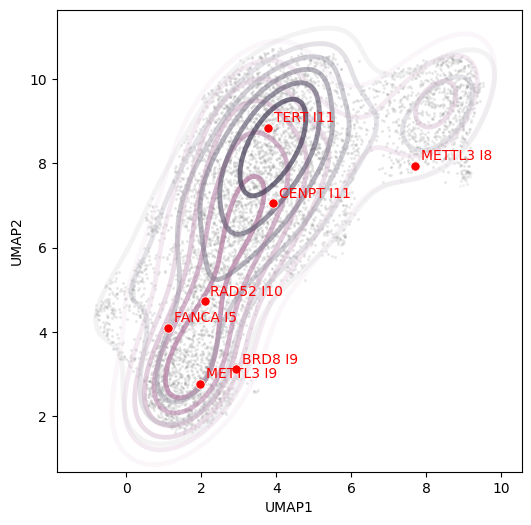

<Axes: xlabel='UMAP1', ylabel='UMAP2'>

In [51]:
plot_2dd_scatter(
    tab_data=tab_umap_fishis,
    contour_col="class_hls",
    x_name="UMAP1",
    y_name="UMAP2",
    scat_alpha=0.2,
    contour_col_classes={'SL-RIs': '#a76794', 'LL-RIs': '#2a1f3f', 'else': 'grey'},
    dlevels=8,
    linewidth=3.5,
    kde_smooth=1.5,
    base_alpha=0.8,
    min_alpha=0.3,
    alpha_decay="linear",
    decay_rate=2.0,
    highlight_ids=fishis,
    highlight_label_map=fishis_labels,
    highlight_label_fontsize=10,
    fig_size=(6, 6),
    show_plot=True,
    return_fig=False,
    file_name=os.path.join(dir_plotting, 'SFN_umap_ProjCandidates.svg')
)